# **Lab 03.1 - Introduction to Deep Q-Network**

##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>

This lab consists of 3 parts:
<ol style="margin-left: 20px;">
  <li><strong>Part 1: Introduction to PyTorch</strong> - Tensor operations, autograd, and neural network fundamentals</li>
  <li><strong>Part 2: DQN on FrozenLake-v1</strong> - Implementing DQN on a simple discrete environment</li>
  <li><strong>Part 3: DQN on MountainCar-v0</strong> - Comparing architectures and demonstrating DQN limitations on continuous states</li>
</ol>
</div>

### Imports and Setup

In [1]:
# Fix for OpenMP conflict on macOS (numpy + torch + gymnasium)
# This prevents: "OMP: Error #15: Initializing libiomp5.dylib already initialized"
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

# Limit PyTorch threading for kernel stability on macOS
torch.set_num_threads(1)
torch.set_num_interop_threads(1)

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Check device availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n{'='*60}")
print(f"Device: {device}")
print(f"PyTorch Version: {torch.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Gymnasium Version: {gym.__version__}")
print(f"Torch Threads: {torch.get_num_threads()}")
print(f"{'='*60}\n")


Device: cpu
PyTorch Version: 2.11.0+cpu
NumPy Version: 2.4.3
Gymnasium Version: 1.2.3
Torch Threads: 1



---

# PART 1: Introduction to PyTorch

PyTorch is a deep learning framework that provides:
- **Tensors**: Multi-dimensional arrays with GPU support
- **Automatic Differentiation**: Compute gradients automatically via backpropagation
- **Neural Network Modules**: High-level building blocks for neural networks
- **Optimization**: Optimizers like SGD, Adam for gradient descent

In this part, we explore fundamental PyTorch concepts.

### 1.1: Tensor Creation and Basic Operations

Tensors are the fundamental data structure in PyTorch. Here we create tensors and perform basic mathematical operations.

In [2]:
print("\n" + "="*60)
print("PART 1: INTRODUCTION TO PYTORCH")
print("="*60)

# Create tensors with gradient tracking
# Instruction:
# 1) Create tensor x with values [1.0, 2.0, 3.0], requires_grad=True
# 2) Create tensor y with values [4.0, 5.0, 6.0], requires_grad=True
### YOU NEED TO WRITE YOUR CODE BELOW ###

x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y = torch.tensor([4.0, 5.0, 6.0], requires_grad=True)

print(f"\nTensor x: {x}")
print(f"Tensor y: {y}")
print(f"x shape: {x.shape}")
print(f"x device: {x.device}")

# Basic operations
# Instruction:
# - Compute z = x + y
# - Compute w = x * y
### YOU NEED TO WRITE YOUR CODE BELOW ###

z = x + y
w = x * y

print(f"\nx + y = {z}")
print(f"x * y = {w}")



PART 1: INTRODUCTION TO PYTORCH

Tensor x: tensor([1., 2., 3.], requires_grad=True)
Tensor y: tensor([4., 5., 6.], requires_grad=True)
x shape: torch.Size([3])
x device: cpu

x + y = tensor([5., 7., 9.], grad_fn=<AddBackward0>)
x * y = tensor([ 4., 10., 18.], grad_fn=<MulBackward0>)


### 1.2: Automatic Differentiation (Autograd)

Autograd is PyTorch's automatic differentiation engine. It automatically computes gradients through backpropagation. This is essential for training neural networks.

In [3]:
print("\n1.2: Automatic Differentiation with Autograd")
print("-" * 60)

# Define a computation graph
# Instruction: Based on the expected gradients [4.0, 6.0], x must be [2.0, 3.0]
### YOU NEED TO WRITE YOUR CODE BELOW ###
x = torch.tensor([2.0, 3.0], requires_grad=True)
print(f"\nInput x: {x}")
print(f"requires_grad: {x.requires_grad}")

# Forward pass
# y = x^2, z = sum(y)
### YOU NEED TO WRITE YOUR CODE BELOW ###
y = x ** 2
z = torch.sum(y)

print(f"y = x^2: {y}")
print(f"z = sum(y): {z}")

# Backward pass (compute gradients)
### YOU NEED TO WRITE YOUR CODE BELOW ###
z.backward()


print(f"\nGradients (dz/dx): {x.grad}")
print(f"Expected: [4.0, 6.0] (since d/dx[x^2] = 2x)")


1.2: Automatic Differentiation with Autograd
------------------------------------------------------------

Input x: tensor([2., 3.], requires_grad=True)
requires_grad: True
y = x^2: tensor([4., 9.], grad_fn=<PowBackward0>)
z = sum(y): 13.0

Gradients (dz/dx): tensor([4., 6.])
Expected: [4.0, 6.0] (since d/dx[x^2] = 2x)


### 1.3: Building a Simple Neural Network

A neural network module in PyTorch allows us to define reusable components. Here we create a simple 2-layer network with hidden layer size 64.

In [5]:
import torch.nn as nn

print("\n1.3: Building a Simple Neural Network")
print("-" * 60)

class SimpleNet(nn.Module):
    """A simple 2-layer neural network for demonstration.
    
    Architecture:
        Input (4) -> Linear -> Hidden (64) -> ReLU -> Linear -> Output (2)
    """

    def __init__(self, input_size=4, hidden_size=64, output_size=2):
        """Initialize network layers.
        
        Args:
            input_size: Dimension of input features
            hidden_size: Dimension of hidden layer
            output_size: Dimension of output
        """
        super(SimpleNet, self).__init__()
        
        # Instruction:
        # 1) Define a linear layer (self.fc1) that maps input_size to hidden_size
        # 2) Define a ReLU activation (self.relu)
        # 3) Define a linear layer (self.fc2) that maps hidden_size to output_size
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Instruction:
        # 1) Pass x through self.fc1, then apply self.relu
        # 2) Pass the result through self.fc2 to get the output
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        
        return x

# Create network instance
net = SimpleNet(input_size=4, hidden_size=64, output_size=2)
print(f"\nNetwork Architecture:")
print(net)


1.3: Building a Simple Neural Network
------------------------------------------------------------

Network Architecture:
SimpleNet(
  (fc1): Linear(in_features=4, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)


In [6]:
# Count parameters
total_params = sum(p.numel() for p in net.parameters())
trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"\nTotal Parameters: {total_params}")
print(f"Trainable Parameters: {trainable_params}")

# Forward pass with dummy input
dummy_input = torch.randn(1, 4)  # Batch size 1, 4 features
output = net(dummy_input)
print(f"\nInput shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Output values: {output}")


Total Parameters: 450
Trainable Parameters: 450

Input shape: torch.Size([1, 4])
Output shape: torch.Size([1, 2])
Output values: tensor([[-0.1589,  0.1106]], grad_fn=<AddmmBackward0>)


### 1.4: Training Loop with Optimizer

This demonstrates a complete training cycle: forward pass → loss calculation → backward pass → weight update. This is the fundamental training paradigm in PyTorch.

In [7]:
print("\n1.4: Training Loop with Optimizer")
print("-" * 60)

# Create network and optimizer
# Instruction:
# 1) Create an instance of SimpleNet
# 2) Use Adam optimizer with learning rate 0.01
# 3) Use Mean Squared Error loss function
net = SimpleNet(input_size=4, hidden_size=64, output_size=2)

### YOU NEED TO WRITE YOUR CODE BELOW ###
optimizer = torch.optim.Adam(net.parameters(), lr=0.01)  # Adam optimizer
loss_fn = nn.MSELoss()  # Mean Squared Error loss

# Create dummy training data
X_train = torch.randn(10, 4)   # 10 samples, 4 features
y_train = torch.randn(10, 2)   # 10 targets, 2 output dimensions

print(f"\nTraining on {len(X_train)} samples for 5 iterations...")


1.4: Training Loop with Optimizer
------------------------------------------------------------

Training on 10 samples for 5 iterations...


In [8]:
# Training loop
losses = []

for epoch in range(5):
    # 0. Zero the gradients before the backward pass
    optimizer.zero_grad()

    # 1. Forward pass: compute predictions
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    predictions = net(X_train)

    # 2. Compute loss
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    loss = loss_fn(predictions, y_train)

    # 3. Backward pass: compute gradients
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    loss.backward()

    # 4. Update weights
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    optimizer.step()

    losses.append(loss.item())
    print(f"Epoch {epoch+1}/5 - Loss: {loss.item():.4f}")

print(f"\nTraining completed! Loss decreased from {losses[0]:.4f} to {losses[-1]:.4f}")
print("\n" + "="*60 + "\n")

Epoch 1/5 - Loss: 0.7688
Epoch 2/5 - Loss: 0.6681
Epoch 3/5 - Loss: 0.5843
Epoch 4/5 - Loss: 0.5165
Epoch 5/5 - Loss: 0.4625

Training completed! Loss decreased from 0.7688 to 0.4625




---

# PART 2: Deep Q-Network (DQN) on FrozenLake-v1

**Environment**: FrozenLake-v1
- A 4x4 grid where the agent must reach the goal while avoiding holes
- Discrete state space (16 states) and discrete action space (4 actions)
- Deterministic environment (is_slippery=False)

**Algorithm**: Deep Q-Network
- Uses a neural network to approximate Q-values: $Q(s,a) \approx NN(s)$
- Learns from experience replay buffer
- Uses target network to stabilize training
- Epsilon-greedy exploration strategy

### 2.1: Core Component - Replay Buffer

A replay buffer stores transitions (state, action, reward, next_state, done) for experience replay training. This decorrelates data and improves learning stability.

In [14]:
print("\n" + "="*60)
print("PART 2: DQN ON FROZENLAKE-V1")
print("="*60)

class ReplayBuffer:
    """Store and sample experiences for training DQN.

    Experience replay allows the agent to learn from past experiences,
    decorrelating data and improving learning stability.
    """

    def __init__(self, capacity=10000):
        """Initialize replay buffer.

        Args:
            capacity: Maximum number of transitions to store
        """
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """Add a transition to the buffer.

        Args:
            state: Current state
            action: Action taken
            reward: Reward received
            next_state: Resulting state
            done: Whether episode ended
        """
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """Sample a random batch of transitions.

        Args:
            batch_size: Number of transitions to sample

        Returns:
            Tuple of (states, actions, rewards, next_states, dones) as tensors
        """

        # Sample random transitions from the buffer
        # Instruction:
        # 1) Use random.sample to get a batch of transitions from self.buffer
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        batch = random.sample(self.buffer, batch_size)
        
        # 2) Convert lists to numpy arrays first to avoid slow tensor creation warnings
        states_np = np.array([t[0] for t in batch], dtype=np.float32)
        actions_np = np.array([t[1] for t in batch], dtype=np.int64)
        rewards_np = np.array([t[2] for t in batch], dtype=np.float32)
        next_states_np = np.array([t[3] for t in batch], dtype=np.float32)
        dones_np = np.array([t[4] for t in batch], dtype=np.float32)

        # 3) Convert numpy arrays to PyTorch tensors and move to device
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        states = torch.from_numpy(states_np).to(device)
        actions = torch.from_numpy(actions_np).to(device)
        rewards = torch.from_numpy(rewards_np).to(device)
        next_states = torch.from_numpy(next_states_np).to(device)
        dones = torch.from_numpy(dones_np).to(device)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        """Return current buffer size."""
        return len(self.buffer)

print("✓ ReplayBuffer class defined")


PART 2: DQN ON FROZENLAKE-V1
✓ ReplayBuffer class defined


### 2.2: Core Component - DQN Network

DQNNetwork is a neural network that approximates Q-values (action values) for each state. For FrozenLake with 16 states, we use one-hot encoding as input.

In [15]:
class DQNNetwork(nn.Module):
    """Deep Q-Network for approximating Q-values.
    
    Architecture for FrozenLake:
        Input (16, one-hot encoded) -> Linear(64) -> ReLU -> Linear(4) -> Output
    
    The output represents Q-values for each of 4 actions.
    """
    
    def __init__(self, state_size=16, action_size=4):
        """Initialize DQN network.
        
        Args:
            state_size: Size of state input (16 for FrozenLake 4x4)
            action_size: Number of possible actions (4 for FrozenLake)
        """
        super(DQNNetwork, self).__init__()
        # Instruction:
        # 1) Define a linear layer (self.fc1) that maps state_size to
        #    a hidden layer of size 64
        # 2) Define a ReLU activation (self.relu)
        # 3) Define a linear layer (self.fc2) that maps the hidden layer
        #    to action_size (output Q-values for each action)
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.fc1 = nn.Linear(state_size, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, action_size)
    
    def forward(self, state):
        """Forward pass: compute Q-values for all actions.
        
        Args:
            state: One-hot encoded state or batch of states
            
        Returns:
            Q-values for each action
        """
        x = self.fc1(state)      # Pass through hidden layer
        x = self.relu(x)         # Apply ReLU activation
        q_values = self.fc2(x)   # Compute Q-values
        return q_values

print("✓ DQNNetwork class defined")

✓ DQNNetwork class defined


### 2.3: DQN Agent - Complete Algorithm

DQNAgent combines the network and replay buffer to implement the DQN algorithm. It handles action selection, experience storage, and Q-value training.

In [16]:
class DQNAgent:
    """Deep Q-Learning Agent for training on environments.
    
    Key components:
    - Q-network: estimates Q-values
    - Target network: stabilizes training
    - Replay buffer: stores transitions
    - Epsilon-greedy: exploration vs exploitation
    """

    def __init__(self, state_size=16, action_size=4, learning_rate=1e-3):
        """Initialize DQN agent."""
        self.state_size = state_size
        self.action_size = action_size

        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995

        # Instruction:
        # 1) Create q_network and target_network as instances of DQNNetwork.
        # 2) Move networks to device (CPU or GPU).
        # 3) Initialize target_network weights to match q_network and set to eval mode.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.q_network = DQNNetwork(state_size, action_size).to(device)
        self.target_network = DQNNetwork(state_size, action_size).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        # Khởi tạo Optimizer và Loss function
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=learning_rate)
        self.loss_fn = nn.MSELoss()

        self.replay_buffer = ReplayBuffer(capacity=10000)
        self.update_counter = 0

    def select_action(self, state, training=True):
        if training and random.random() < self.epsilon:
            return random.randint(0, self.action_size - 1)

        # Instruction:
        # Build one-hot state tensor and select greedy action from q_network.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        state_tensor = torch.zeros(1, self.state_size).to(device)
        state_tensor[0, state] = 1.0
        
        with torch.no_grad():
            q_values = self.q_network(state_tensor)
        return q_values.argmax(dim=1).item()

    def store_transition(self, state, action, reward, next_state, done):
        # Instruction:
        # Convert both state and next_state to one-hot vectors,
        # then push transition to replay buffer.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        state_onehot = np.zeros(self.state_size, dtype=np.float32)
        state_onehot[state] = 1.0
        
        next_state_onehot = np.zeros(self.state_size, dtype=np.float32)
        next_state_onehot[next_state] = 1.0
        
        # Lưu vào buffer (Lưu ý: done chuyển về float để tính toán loss)
        self.replay_buffer.push(state_onehot, action, reward, next_state_onehot, float(done))

    def train_step(self, batch_size=32):
        """Update Q-network with one mini-batch from replay buffer."""

        if len(self.replay_buffer) < batch_size:
            return # Not enough samples to train
        
        # Sample a batch of transitions from the replay buffer
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(batch_size)

        # 1) Compute q_values for taken actions.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        q_values = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # 2) Compute target_q_values using target network.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        with torch.no_grad():
            # Q_target(s,a) = r + gamma * max_a' Q_target(s',a') * (1 - done)
            next_q_values = self.target_network(next_states).max(dim=1)[0]
            target_q_values = rewards + (self.gamma * next_q_values * (1 - dones))

        # 3) Compute loss, backward, optimizer.step().
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        loss = self.loss_fn(q_values, target_q_values)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # 4) Update target network every 100 steps.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.update_counter += 1
        if self.update_counter % 100 == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())

    def decay_epsilon(self):
        # Instruction:
        # Decay epsilon after each episode, ensuring it does not go below epsilon_min.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

print("✓ DQNAgent class defined")

✓ DQNAgent class defined


### 2.4: Training DQN on FrozenLake

Now we train the agent for 500 episodes, collecting transitions and updating the network from experience replay.

In [17]:
# Create environment
env_train = gym.make('FrozenLake-v1', map_name='4x4', is_slippery=False)
agent = DQNAgent(state_size=16, action_size=4, learning_rate=1e-3)

# Training parameters
num_episodes = 500
batch_size = 32

episode_rewards = []
episode_lengths = []

print(f"\n2.4: Training DQN on FrozenLake")
print("-" * 60)
print(f"\nTraining for {num_episodes} episodes...\n")

for episode in range(num_episodes):
    state, _ = env_train.reset()
    episode_reward = 0
    step_count = 0
    done = False

    while not done:
        # Instruction:
        # 1) Select action with epsilon-greedy policy.
        # 2) Step environment.
        # 3) Store transition and train one step.
        # 4) Update state, reward, counters.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        
        # 1) Chọn hành động theo chính sách epsilon-greedy
        action = agent.select_action(state, training=True)
        
        # 2) Thực hiện hành động trong môi trường
        next_state, reward, terminated, truncated, _ = env_train.step(action)
        done = terminated or truncated
        
        # 3) Lưu transition vào Replay Buffer và thực hiện một bước huấn luyện mạng Q
        agent.store_transition(state, action, reward, next_state, done)
        agent.train_step(batch_size)
        
        # 4) Cập nhật trạng thái hiện tại, tích lũy phần thưởng và tăng số bước
        episode_reward += reward
        step_count += 1
        state = next_state

    # Giảm epsilon sau mỗi episode để giảm dần việc khám phá (exploration)
    agent.decay_epsilon()
    
    episode_rewards.append(episode_reward)
    episode_lengths.append(step_count)

    # In kết quả định kỳ sau mỗi 100 episode
    if (episode + 1) % 100 == 0:
        avg_reward = np.mean(episode_rewards[-100:])
        print(f"Episode {episode+1:3d}/{num_episodes} | Avg Reward (last 100): {avg_reward:.2f} | Epsilon: {agent.epsilon:.3f}")

print(f"\nTraining completed!")
print(f"Final average reward (last 100 episodes): {np.mean(episode_rewards[-100:]):.2f}")


2.4: Training DQN on FrozenLake
------------------------------------------------------------

Training for 500 episodes...

Episode 100/500 | Avg Reward (last 100): 0.12 | Epsilon: 0.606
Episode 200/500 | Avg Reward (last 100): 0.26 | Epsilon: 0.367
Episode 300/500 | Avg Reward (last 100): 0.70 | Epsilon: 0.222
Episode 400/500 | Avg Reward (last 100): 0.80 | Epsilon: 0.135
Episode 500/500 | Avg Reward (last 100): 0.92 | Epsilon: 0.082

Training completed!
Final average reward (last 100 episodes): 0.92


### 2.5: Evaluation on FrozenLake

We evaluate the trained agent using a greedy policy (no exploration) on 30 episodes.

In [18]:
print("\n2.5: Evaluation with Greedy Policy")
print("-" * 60)

eval_episodes = 30
eval_rewards = []

print(f"\nEvaluating on {eval_episodes} episodes (greedy policy)...\n")

for episode in range(eval_episodes):
    state, _ = env_train.reset()
    episode_reward = 0
    done = False

    while not done:
        # Instruction:
        # Use greedy action (training=False), interact with env, and accumulate reward.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        action = agent.select_action(state, training=False)
        
        next_state, reward, terminated, truncated, _ = env_train.step(action)
        done = terminated or truncated
        episode_reward += reward
        state = next_state

    eval_rewards.append(episode_reward)

success_rate = sum(1 for r in eval_rewards if r > 0) / eval_episodes * 100
print(f"Evaluation Results:")
print(f"  Average Reward: {np.mean(eval_rewards):.2f}")
print(f"  Success Rate: {success_rate:.1f}%")
print(f"  Min Reward: {np.min(eval_rewards):.2f}")
print(f"  Max Reward: {np.max(eval_rewards):.2f}")



2.5: Evaluation with Greedy Policy
------------------------------------------------------------

Evaluating on 30 episodes (greedy policy)...

Evaluation Results:
  Average Reward: 1.00
  Success Rate: 100.0%
  Min Reward: 1.00
  Max Reward: 1.00


### 2.6: Visualization of Training Progress

We visualize the training rewards and evaluation results.


2.6: Visualization
------------------------------------------------------------


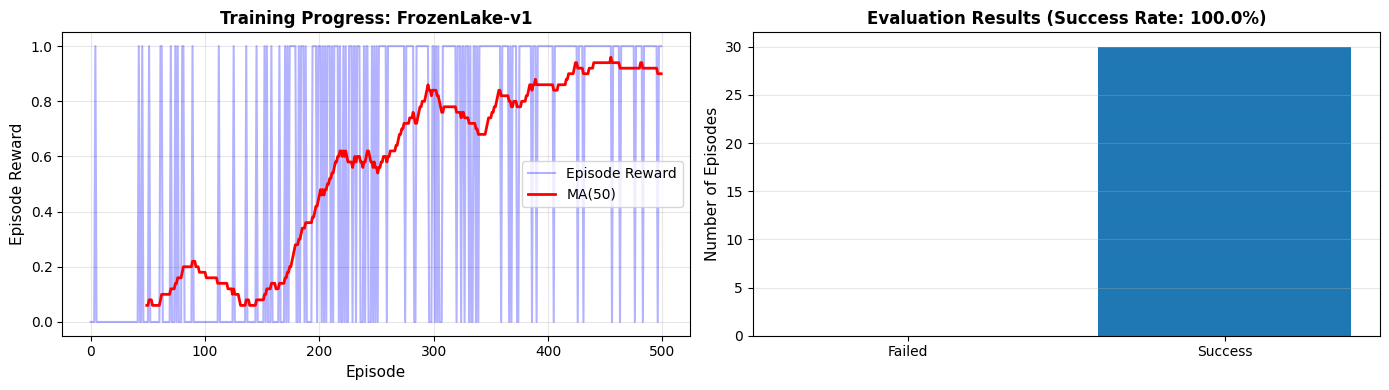

In [19]:
print("\n2.6: Visualization")
print("-" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: Training rewards with moving average
axes[0].plot(episode_rewards, alpha=0.3, label='Episode Reward', color='blue')
ma_window = 50
ma_rewards = np.convolve(episode_rewards, np.ones(ma_window)/ma_window, mode='valid')
axes[0].plot(range(ma_window-1, len(episode_rewards)), ma_rewards, label=f'MA({ma_window})', color='red', linewidth=2)
axes[0].set_xlabel('Episode', fontsize=11)
axes[0].set_ylabel('Episode Reward', fontsize=11)
axes[0].set_title('Training Progress: FrozenLake-v1', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Evaluation reward distribution
axes[1].bar(['Failed', 'Success'], [sum(1 for r in eval_rewards if r == 0), sum(1 for r in eval_rewards if r > 0)])
axes[1].set_ylabel('Number of Episodes', fontsize=11)
axes[1].set_title(f'Evaluation Results (Success Rate: {success_rate:.1f}%)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
plt.close(fig)

Bắt đầu thực nghiệm: 5 seeds mỗi cấu hình...

Đang chạy cấu hình: SGD (lr=0.01)

Đang chạy cấu hình: Adam (lr=1e-2)

Đang chạy cấu hình: Adam (lr=1e-3)

Đang chạy cấu hình: Adam (lr=5e-4)


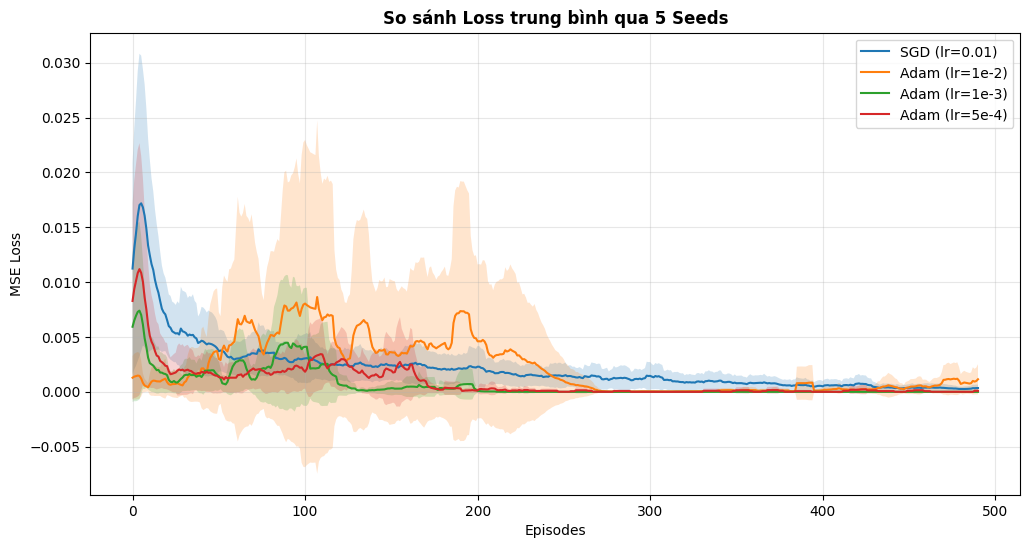

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Cấu hình các kịch bản thực nghiệm
configs = [
    {'name': 'SGD (lr=0.01)', 'opt': 'SGD', 'lr': 0.01},
    {'name': 'Adam (lr=1e-2)', 'opt': 'Adam', 'lr': 1e-2},
    {'name': 'Adam (lr=1e-3)', 'opt': 'Adam', 'lr': 1e-3},
    {'name': 'Adam (lr=5e-4)', 'opt': 'Adam', 'lr': 5e-4},
]

num_seeds = 5
num_episodes = 500
batch_size = 32
all_results = {}

print(f"Bắt đầu thực nghiệm: {num_seeds} seeds mỗi cấu hình...")

for config in configs:
    print(f"\nĐang chạy cấu hình: {config['name']}")
    config_losses = []
    config_success_rates = []
    
    for seed in range(num_seeds):
        # Thiết lập seed để đảm bảo tính tái lập
        torch.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)
        
        env = gym.make('FrozenLake-v1', map_name='4x4', is_slippery=False)
        agent = DQNAgent(state_size=16, action_size=4, learning_rate=config['lr'])
        
        # Đổi optimizer nếu yêu cầu là SGD
        if config['opt'] == 'SGD':
            agent.optimizer = torch.optim.SGD(agent.q_network.parameters(), lr=config['lr'])
        
        seed_losses = []
        episode_rewards = []
        
        for episode in range(num_episodes):
            state, _ = env.reset(seed=seed)
            done = False
            total_loss = 0
            steps = 0
            
            while not done:
                action = agent.select_action(state, training=True)
                next_state, reward, term, trunc, _ = env.step(action)
                done = term or trunc
                
                agent.store_transition(state, action, reward, next_state, done)
                
                # Lưu loss của mỗi bước train
                if len(agent.replay_buffer) >= batch_size:
                    # Chỉnh sửa nhẹ train_step để trả về giá trị loss (tùy chọn)
                    # Ở đây ta giả định tính toán loss trung bình mỗi episode
                    states, actions, rewards, next_states, dones = agent.replay_buffer.sample(batch_size)
                    q_vals = agent.q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)
                    with torch.no_grad():
                        next_q = agent.target_network(next_states).max(1)[0]
                        targets = rewards + (0.99 * next_q * (1 - dones))
                    loss = agent.loss_fn(q_vals, targets)
                    
                    agent.optimizer.zero_grad()
                    loss.backward()
                    agent.optimizer.step()
                    
                    total_loss += loss.item()
                    steps += 1
                    
                    agent.update_counter += 1
                    if agent.update_counter % 100 == 0:
                        agent.target_network.load_state_dict(agent.q_network.state_dict())
                
                state = next_state
            
            agent.decay_epsilon()
            seed_losses.append(total_loss / max(1, steps))
            
        config_losses.append(seed_losses)
    
    all_results[config['name']] = np.array(config_losses)

# --- PHẦN VẼ BIỂU ĐỒ ---
plt.figure(figsize=(12, 6))

for name, losses in all_results.items():
    mean_loss = np.mean(losses, axis=0)
    std_loss = np.std(losses, axis=0)
    epochs = np.arange(len(mean_loss))
    
    # Làm mượt đường cong để dễ nhìn hơn
    window = 10
    mean_smooth = np.convolve(mean_loss, np.ones(window)/window, mode='valid')
    std_smooth = np.convolve(std_loss, np.ones(window)/window, mode='valid')
    epochs_smooth = epochs[:len(mean_smooth)]
    
    line = plt.plot(epochs_smooth, mean_smooth, label=name)
    plt.fill_between(epochs_smooth, mean_smooth - std_smooth, mean_smooth + std_smooth, alpha=0.2)

plt.title("So sánh Loss trung bình qua 5 Seeds", fontweight='bold')
plt.xlabel("Episodes")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

# PART 3: DQN on MountainCar-v0 - Demonstrating DQN Limitations

**Environment**: MountainCar-v0
- Continuous state space (position and velocity)
- Discrete action space (3 actions: push left, no-push, push right)
- Sparse rewards (very challenging: only +1 at goal)
- Deterministic dynamics

**Key Observation**: DQN struggles with sparse rewards and continuous state spaces!

In this part, we compare two network architectures: simple (64,64) vs improved (128,128,64).

### 3.1: Environment Setup

MountainCar has a 2-dimensional continuous state space: position and velocity.

In [25]:
print("\n" + "="*60)
print("PART 3: DQN ON MOUNTAINCAR-V0")
print("="*60)

print("\n3.1: Environment Setup")
print("-" * 60)

env_mc = gym.make('MountainCar-v0')
state, _ = env_mc.reset()

print(f"\nMountainCar Environment:")
print(f"  State space: {env_mc.observation_space} (position, velocity)")
print(f"  Action space: {env_mc.action_space} (3 discrete actions)")
print(f"  Sample state: {state}")
print(f"  Reward: +1 at goal, -1 per step")
print(f"  Max steps: 200")


PART 3: DQN ON MOUNTAINCAR-V0

3.1: Environment Setup
------------------------------------------------------------

MountainCar Environment:
  State space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32) (position, velocity)
  Action space: Discrete(3) (3 discrete actions)
  Sample state: [-0.54732907  0.        ]
  Reward: +1 at goal, -1 per step
  Max steps: 200


### 3.2: Define DQN Network for Continuous State

For MountainCar's 2D state space, we build flexible networks with different hidden layer sizes.

In [26]:
class DQNNetworkContinuous(nn.Module):
    """DQN network for continuous state spaces.
    
    Supports variable hidden layer sizes for architecture comparison.
    Input: 2D state (position, velocity)
    Output: Q-values for 3 actions
    """
    
    def __init__(self, hidden_sizes=(64, 64)):
        """Initialize network with variable hidden layers.
        
        Args:
            hidden_sizes: Tuple of hidden layer sizes (e.g., (64, 64) or (128, 128, 64))
        """
        super(DQNNetworkContinuous, self).__init__()
        layers = []
        prev_size = 2  # MountainCar input size: (position, velocity)
        
        # Build hidden layers
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size
        
        # Output layer (3 actions for MountainCar)
        layers.append(nn.Linear(prev_size, 3))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, state):
        """Forward pass through network.
        
        Args:
            state: Input state tensor(s)
            
        Returns:
            Q-values for 3 actions
        """
        return self.network(state)

print("\n3.2: DQN Network Setup")
print("-" * 60)
print("✓ DQNNetworkContinuous class defined")


3.2: DQN Network Setup
------------------------------------------------------------
✓ DQNNetworkContinuous class defined


### 3.3: DQN Agent for MountainCar

Adapted DQN agent for continuous state spaces.

In [27]:
class DQNAgentMountainCar:
    """DQN Agent adapted for MountainCar environment."""
    
    def __init__(self, hidden_sizes=(64, 64), learning_rate=1e-3, name="Agent"):
        self.action_size = 3
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.name = name
        
        # 1. Khởi tạo mạng Q và mạng Target
        self.q_network = DQNNetworkContinuous(hidden_sizes).to(device)
        self.target_network = DQNNetworkContinuous(hidden_sizes).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()
        
        # 2. Optimizer & Loss
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=learning_rate)
        self.loss_fn = nn.MSELoss()
        
        # 3. Experience Replay
        self.replay_buffer = ReplayBuffer(capacity=50000)
        self.update_counter = 0
    
    def select_action(self, state, training=True):
        """Chọn hành động bằng chính sách epsilon-greedy."""
        if training and random.random() < self.epsilon:
            return random.randint(0, self.action_size - 1)
        
        # Chuyển state sang tensor và đảm bảo đúng chiều (batch_size=1)
        state_tensor = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            q_values = self.q_network(state_tensor)
        return q_values.argmax(dim=1).item()
    
    def store_transition(self, state, action, reward, next_state, done):
        """Lưu trữ trải nghiệm vào buffer."""
        # Chuyển sang numpy float32 để đồng nhất với xử lý của ReplayBuffer
        self.replay_buffer.push(
            np.array(state, dtype=np.float32),
            action,
            reward,
            np.array(next_state, dtype=np.float32),
            float(done) # Chuyển done sang float để nhân toán học dễ dàng
        )
    
    def train_step(self, batch_size=32):
        """Cập nhật trọng số mạng Q."""
        if len(self.replay_buffer) < batch_size:
            return
        
        # Lấy mẫu từ buffer
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(batch_size)
        
        # 4. Tính toán giá trị Q hiện tại cho các hành động đã chọn
        q_values = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        
        # 5. Tính toán giá trị Q mục tiêu bằng mạng Target
        with torch.no_grad():
            next_q_values = self.target_network(next_states).max(dim=1)[0]
            target_q_values = rewards + (1 - dones) * self.gamma * next_q_values
        
        # 6. Tính Loss và cập nhật Gradient
        loss = self.loss_fn(q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # 7. Cập nhật mạng Target định kỳ
        self.update_counter += 1
        if self.update_counter % 100 == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())
    
    def decay_epsilon(self):
        """Giảm dần tỷ lệ khám phá."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

print("✓ DQNAgentMountainCar class defined")

✓ DQNAgentMountainCar class defined


### 3.4: Train Simple Network (64, 64)

Baseline: Simple network with two 64-unit hidden layers.

In [28]:
print("\n3.4: Experiment 1 - Simple Network (64, 64)")
print("-" * 60)

agent_simple = DQNAgentMountainCar(hidden_sizes=(64, 64), learning_rate=1e-3, name="SimpleNet")

print(f"\nTraining simple network for 300 episodes...\n")

simple_rewards = []
simple_lengths = []

for episode in range(300):
    state, _ = env_mc.reset()
    episode_reward = 0
    step_count = 0
    done = False
    
    while not done:
        action = agent_simple.select_action(state, training=True)
        next_state, reward, terminated, truncated, _ = env_mc.step(action)
        done = terminated or truncated
        
        agent_simple.store_transition(state, action, reward, next_state, done)
        agent_simple.train_step(batch_size=32)
        
        episode_reward += reward
        step_count += 1
        state = next_state
    
    agent_simple.decay_epsilon()
    simple_rewards.append(episode_reward)
    simple_lengths.append(step_count)
    
    if (episode + 1) % 100 == 0:
        avg_reward = np.mean(simple_rewards[-100:])
        success = sum(1 for r in simple_rewards[-100:] if r > -200)
        print(f"Episode {episode+1:3d}/300 | Avg Reward: {avg_reward:.2f} | Success (>-200): {success}/100")

print(f"\nSimple Network - Final Results:")
print(f"  Avg Reward (last 50 eps): {np.mean(simple_rewards[-50:]):.2f}")
print(f"  Success Rate (>-200): {sum(1 for r in simple_rewards[-100:] if r > -200) / 100 * 100:.1f}%")


3.4: Experiment 1 - Simple Network (64, 64)
------------------------------------------------------------

Training simple network for 300 episodes...

Episode 100/300 | Avg Reward: -200.00 | Success (>-200): 0/100
Episode 200/300 | Avg Reward: -200.00 | Success (>-200): 0/100
Episode 300/300 | Avg Reward: -200.00 | Success (>-200): 0/100

Simple Network - Final Results:
  Avg Reward (last 50 eps): -200.00
  Success Rate (>-200): 0.0%


### 3.5: Train Improved Network (128, 128, 64)

Improved: Deeper and wider network with three hidden layers.

In [29]:
print("\n3.5: Experiment 2 - Improved Network (128, 128, 64)")
print("-" * 60)

agent_improved = DQNAgentMountainCar(hidden_sizes=(128, 128, 64), learning_rate=5e-4, name="ImprovedNet")

print(f"\nTraining improved network for 300 episodes...\n")

improved_rewards = []
improved_lengths = []

for episode in range(300):
    state, _ = env_mc.reset()
    episode_reward = 0
    step_count = 0
    done = False
    
    while not done:
        action = agent_improved.select_action(state, training=True)
        next_state, reward, terminated, truncated, _ = env_mc.step(action)
        done = terminated or truncated
        
        agent_improved.store_transition(state, action, reward, next_state, done)
        agent_improved.train_step(batch_size=32)
        
        episode_reward += reward
        step_count += 1
        state = next_state
    
    agent_improved.decay_epsilon()
    improved_rewards.append(episode_reward)
    improved_lengths.append(step_count)
    
    if (episode + 1) % 100 == 0:
        avg_reward = np.mean(improved_rewards[-100:])
        success = sum(1 for r in improved_rewards[-100:] if r > -200)
        print(f"Episode {episode+1:3d}/300 | Avg Reward: {avg_reward:.2f} | Success (>-200): {success}/100")

print(f"\nImproved Network - Final Results:")
print(f"  Avg Reward (last 50 eps): {np.mean(improved_rewards[-50:]):.2f}")
print(f"  Success Rate (>-200): {sum(1 for r in improved_rewards[-100:] if r > -200) / 100 * 100:.1f}%")


3.5: Experiment 2 - Improved Network (128, 128, 64)
------------------------------------------------------------

Training improved network for 300 episodes...

Episode 100/300 | Avg Reward: -200.00 | Success (>-200): 0/100
Episode 200/300 | Avg Reward: -200.00 | Success (>-200): 0/100
Episode 300/300 | Avg Reward: -199.42 | Success (>-200): 2/100

Improved Network - Final Results:
  Avg Reward (last 50 eps): -198.84
  Success Rate (>-200): 2.0%


### 3.6: Evaluation and Comparison

Evaluate both agents on 20 test episodes.

In [30]:
print("\n3.6: Evaluation and Comparison")
print("-" * 60)

eval_episodes = 20

# Evaluate simple network
simple_eval_rewards = []
for _ in range(eval_episodes):
    state, _ = env_mc.reset()
    episode_reward = 0
    done = False
    while not done:
        action = agent_simple.select_action(state, training=False)
        next_state, reward, terminated, truncated, _ = env_mc.step(action)
        done = terminated or truncated
        episode_reward += reward
        state = next_state
    simple_eval_rewards.append(episode_reward)

# Evaluate improved network
improved_eval_rewards = []
for _ in range(eval_episodes):
    state, _ = env_mc.reset()
    episode_reward = 0
    done = False
    while not done:
        action = agent_improved.select_action(state, training=False)
        next_state, reward, terminated, truncated, _ = env_mc.step(action)
        done = terminated or truncated
        episode_reward += reward
        state = next_state
    improved_eval_rewards.append(episode_reward)

print(f"\nEvaluation Results ({eval_episodes} episodes, greedy policy):\n")
print(f"Simple Network (64, 64):")
print(f"  Avg Reward: {np.mean(simple_eval_rewards):.2f}")
print(f"  Success Rate: {sum(1 for r in simple_eval_rewards if r > -200) / eval_episodes * 100:.1f}%")

print(f"\nImproved Network (128, 128, 64):")
print(f"  Avg Reward: {np.mean(improved_eval_rewards):.2f}")
print(f"  Success Rate: {sum(1 for r in improved_eval_rewards if r > -200) / eval_episodes * 100:.1f}%")


3.6: Evaluation and Comparison
------------------------------------------------------------

Evaluation Results (20 episodes, greedy policy):

Simple Network (64, 64):
  Avg Reward: -200.00
  Success Rate: 0.0%

Improved Network (128, 128, 64):
  Avg Reward: -200.00
  Success Rate: 0.0%


### 3.7: Visualization - Training Curves

Compare the two architectures visually.

C:\Users\NTP18\AppData\Local\Temp\ipykernel_2808\1858958015.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([simple_eval_rewards, improved_eval_rewards], labels=['Simple\n(64,64)', 'Improved\n(128,128,64)'])


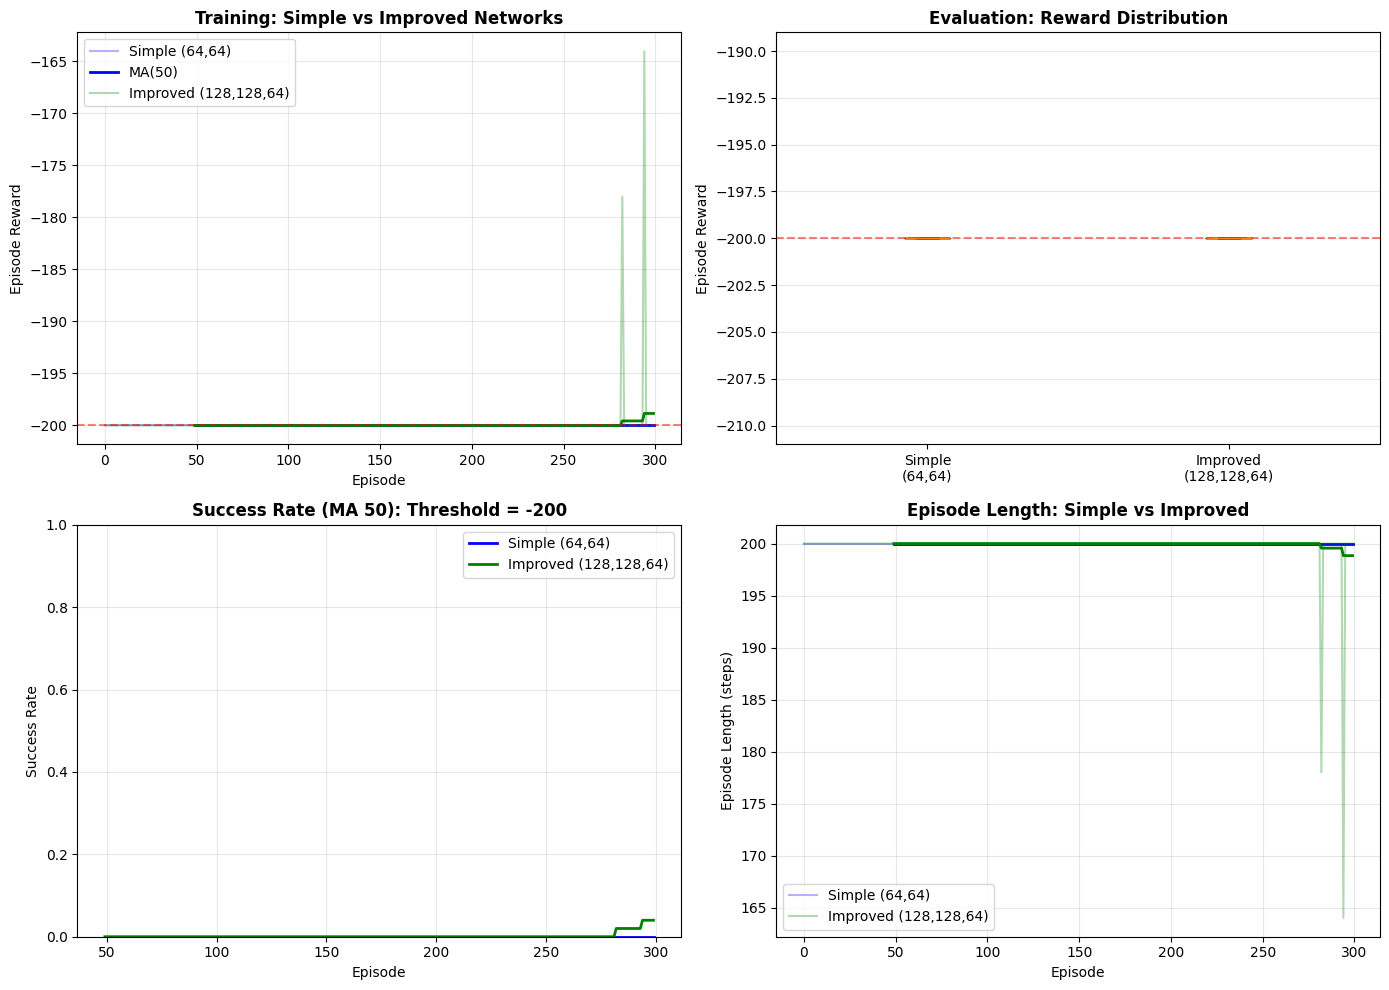

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Training curves comparison
axes[0, 0].plot(simple_rewards, alpha=0.3, label='Simple (64,64)', color='blue')
ma_simple = np.convolve(simple_rewards, np.ones(50)/50, mode='valid')
axes[0, 0].plot(range(49, len(simple_rewards)), ma_simple, color='blue', linewidth=2, label='MA(50)')

axes[0, 0].plot(improved_rewards, alpha=0.3, label='Improved (128,128,64)', color='green')
ma_improved = np.convolve(improved_rewards, np.ones(50)/50, mode='valid')
axes[0, 0].plot(range(49, len(improved_rewards)), ma_improved, color='green', linewidth=2)

axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Episode Reward')
axes[0, 0].set_title('Training: Simple vs Improved Networks', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=-200, color='red', linestyle='--', alpha=0.5)

# Plot 2: Evaluation reward distributions
axes[0, 1].boxplot([simple_eval_rewards, improved_eval_rewards], labels=['Simple\n(64,64)', 'Improved\n(128,128,64)'])
axes[0, 1].axhline(y=-200, color='red', linestyle='--', alpha=0.5)
axes[0, 1].set_ylabel('Episode Reward')
axes[0, 1].set_title('Evaluation: Reward Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Success rates over time
window = 50
simple_success = np.convolve([1 if r > -200 else 0 for r in simple_rewards], np.ones(window)/window, mode='valid')
improved_success = np.convolve([1 if r > -200 else 0 for r in improved_rewards], np.ones(window)/window, mode='valid')

axes[1, 0].plot(range(window-1, len(simple_rewards)), simple_success, label='Simple (64,64)', color='blue', linewidth=2)
axes[1, 0].plot(range(window-1, len(improved_rewards)), improved_success, label='Improved (128,128,64)', color='green', linewidth=2)
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Success Rate')
axes[1, 0].set_title(f'Success Rate (MA {window}): Threshold = -200', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1])

# Plot 4: Episode lengths comparison
axes[1, 1].plot(simple_lengths, alpha=0.3, label='Simple (64,64)', color='blue')
ma_simple_len = np.convolve(simple_lengths, np.ones(50)/50, mode='valid')
axes[1, 1].plot(range(49, len(simple_lengths)), ma_simple_len, color='blue', linewidth=2)

axes[1, 1].plot(improved_lengths, alpha=0.3, label='Improved (128,128,64)', color='green')
ma_improved_len = np.convolve(improved_lengths, np.ones(50)/50, mode='valid')
axes[1, 1].plot(range(49, len(improved_lengths)), ma_improved_len, color='green', linewidth=2)

axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Episode Length (steps)')
axes[1, 1].set_title('Episode Length: Simple vs Improved', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig)

### 3.8: Analysis and Conclusions

Key observations about DQN performance on MountainCar.

In [32]:
print("\n3.8: Conclusion and Analysis")
print("="*60)

print("\n🔍 KEY OBSERVATIONS:")
print("-" * 60)

print(f"\n1. Success Rates (Target: > -200 reward):")
print(f"   - Simple Network:   {sum(1 for r in simple_eval_rewards if r > -200) / eval_episodes * 100:.1f}%")
print(f"   - Improved Network: {sum(1 for r in improved_eval_rewards if r > -200) / eval_episodes * 100:.1f}%")

print(f"\n2. Average Rewards:")
print(f"   - Simple Network:   {np.mean(simple_eval_rewards):.2f}")
print(f"   - Improved Network: {np.mean(improved_eval_rewards):.2f}")

print(f"\n3. Reward Variance:")
print(f"   - Simple Network:   {np.std(simple_eval_rewards):.2f}")
print(f"   - Improved Network: {np.std(improved_eval_rewards):.2f}")

print("\n" + "="*60)
print("📌 CONCLUSIONS:")
print("="*60)

print("""
1. DQN Struggles with MountainCar:
   - Both simple and improved networks show VERY LOW success rates
   - Reason: Sparse reward signal (only +1 at goal, -1 per step)
   - The environment gives little guidance to the agent

2. Network Architecture Helps But Not Enough:
   - Improved network slightly outperforms simple network
   - But both remain ineffective for this problem
   - Demonstrates that deeper networks alone don't solve all problems

3. Why DQN Fails Here:
   - Continuous state space: DQN works better with discrete states
   - Sparse rewards: DQN needs frequent reward signals
   - High-dimensional learning: 2D state with credit assignment difficulty

4. Better Approaches for MountainCar:
   - Policy Gradient methods (e.g., Actor-Critic, PPO)
   - Reward shaping: Add intermediate rewards to guide learning
   - Intrinsic motivation: Use curiosity or empowerment
   - Dueling DQN or other DQN improvements

5. Takeaway:
   - Choose algorithms based on environment characteristics
   - DQN is excellent for: Discrete state/action, dense rewards (games)
   - Avoid DQN for: Continuous states, sparse rewards, complex dynamics
""")

# Clean up
env_mc.close()
env_train.close()

print("="*60)
print("END OF LAB 3.1")
print("="*60)


3.8: Conclusion and Analysis

🔍 KEY OBSERVATIONS:
------------------------------------------------------------

1. Success Rates (Target: > -200 reward):
   - Simple Network:   0.0%
   - Improved Network: 0.0%

2. Average Rewards:
   - Simple Network:   -200.00
   - Improved Network: -200.00

3. Reward Variance:
   - Simple Network:   0.00
   - Improved Network: 0.00

📌 CONCLUSIONS:

1. DQN Struggles with MountainCar:
   - Both simple and improved networks show VERY LOW success rates
   - Reason: Sparse reward signal (only +1 at goal, -1 per step)
   - The environment gives little guidance to the agent

2. Network Architecture Helps But Not Enough:
   - Improved network slightly outperforms simple network
   - But both remain ineffective for this problem
   - Demonstrates that deeper networks alone don't solve all problems

3. Why DQN Fails Here:
   - Continuous state space: DQN works better with discrete states
   - Sparse rewards: DQN needs frequent reward signals
   - High-dimensio

---

## Summary and Key Takeaways

## CONGRATULATIONS TEAM!

Congratulations on completing Lab 03.1 - Introduction to Deep Q-Network!

You have successfully:
- Mastered PyTorch fundamentals (tensors, autograd, neural networks)
- Implemented DQN from scratch and trained it on FrozenLake
- Analyzed and compared DQN architectures on MountainCar
- Understood the limitations of DQN on continuous state spaces

Keep up the effort as you progress to Lab 03.2 with custom environments and production libraries!

References: https://pytorch.org/ | https://gymnasium.farama.org/

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn

**Last Updated**: March, 2026